In [1]:
import os
import json
import random
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

# Настройка визуализации
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12

# %%
# Фиксация seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
set_seed(SEED)

# Определение устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


2.3.2. Данные и первичный анализ

Исходный размер датасета: (4320, 2)
Колонки: ['date', 'target']


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62



Диапазон дат: 2025-01-01 00:00:00 → 2025-06-29 23:00:00
Число наблюдений: 4320
Пропуски по колонкам:
date      0
target    0
dtype: int64


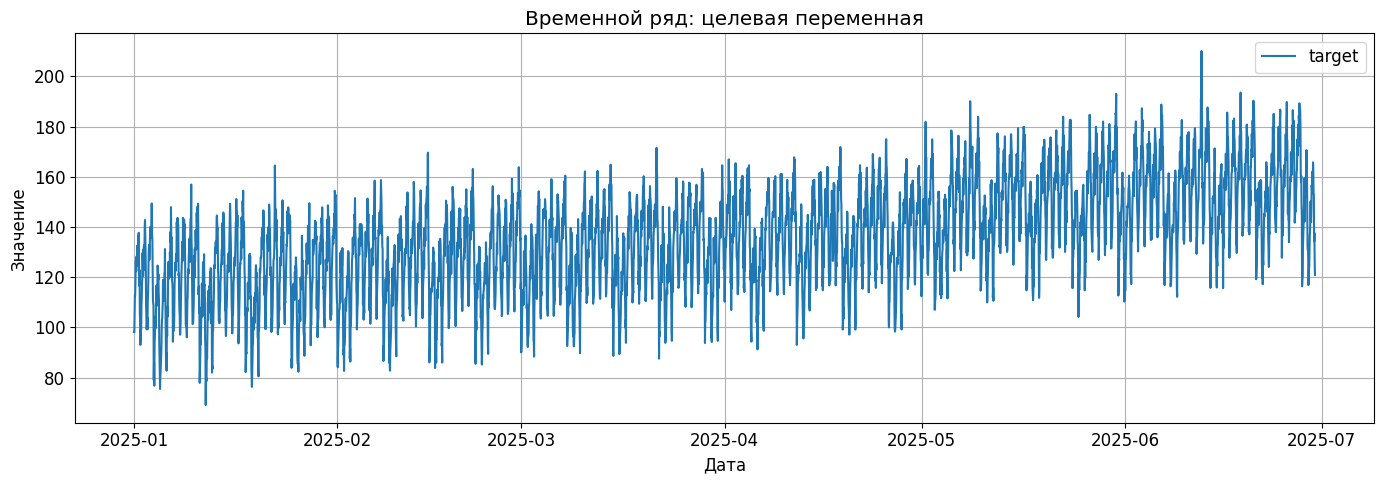

In [2]:
DATA_PATH = 'S12-hw-dataset.csv'  
df = pd.read_csv(DATA_PATH)

print(f'Исходный размер датасета: {df.shape}')
print(f'Колонки: {df.columns.tolist()}')
display(df.head())

# Приведение date к datetime и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'\nДиапазон дат: {df["date"].min()} → {df["date"].max()}')
print(f'Число наблюдений: {len(df)}')
print(f'Пропуски по колонкам:\n{df.isnull().sum()}')

# Обработка пропусков (если есть)
if df.isnull().sum().sum() > 0:
    print('\nОбнаружены пропуски. Применяем forward fill для target.')
    df['target'] = df['target'].ffill().bfill()
    df = df.dropna().reset_index(drop=True)
    print(f'Размер после обработки пропусков: {len(df)}')

# Базовый график временного ряда
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['date'], df['target'], lw=1.5, label='target')
ax.set_title('Временной ряд: целевая переменная')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
ax.legend()
plt.tight_layout()
plt.show()

2.3.3. Корректный temporal split

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


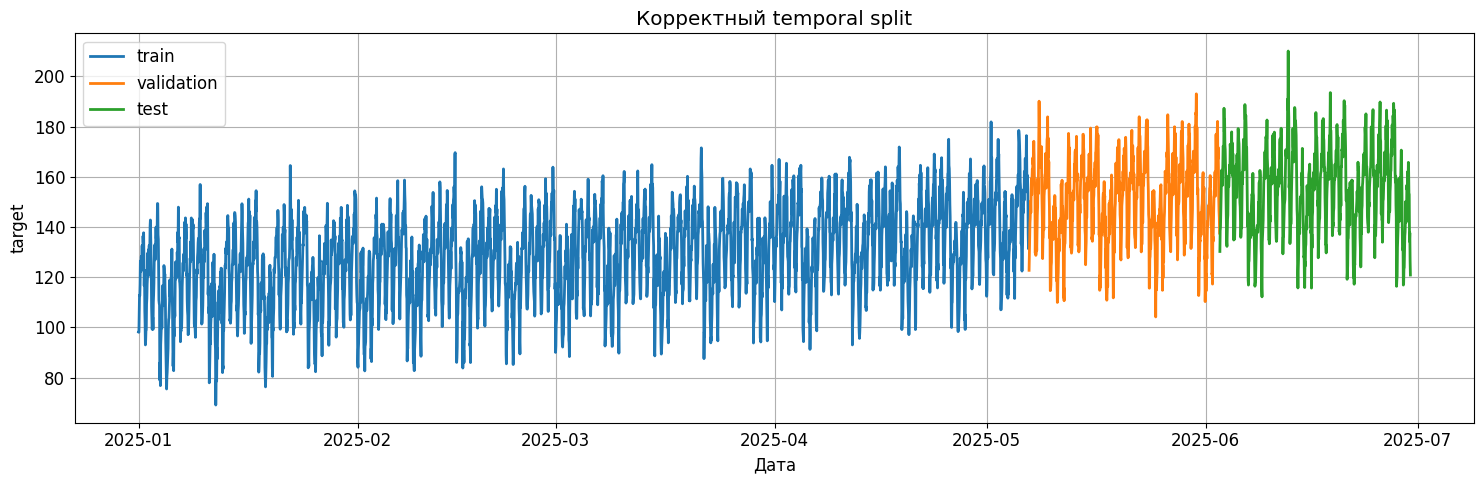

In [3]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """Разбиение временного ряда по хронологии."""
    assert abs(cfg.train_frac + cfg.val_frac + cfg.test_frac - 1.0) < 1e-9
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))
    
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    
    return train_df, val_df, test_df

cfg = SplitConfig()
train_df, val_df, test_df = temporal_split(df, cfg)

print(f'train: {train_df["date"].min().date()} → {train_df["date"].max().date()} | {len(train_df)} строк')
print(f'val:   {val_df["date"].min().date()} → {val_df["date"].max().date()} | {len(val_df)} строк')
print(f'test:  {test_df["date"].min().date()} → {test_df["date"].max().date()} | {len(test_df)} строк')


# Визуализация split
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(train_df['date'], train_df['target'], label='train', lw=2)
ax.plot(val_df['date'], val_df['target'], label='validation', lw=2)
ax.plot(test_df['date'], test_df['target'], label='test', lw=2)
ax.set_title('Корректный temporal split')
ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

2.3.4. Признаки для baseline-моделей

In [4]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет календарные признаки."""
    out = df.copy()
    out['dayofweek'] = out['date'].dt.dayofweek
    out['month'] = out['date'].dt.month
    out['dayofyear'] = out['date'].dt.dayofyear
    
    # Циклическое кодирование
    out['dow_sin'] = np.sin(2 * np.pi * out['dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['dayofweek'] / 7)
    out['month_sin'] = np.sin(2 * np.pi * out['month'] / 12)
    out['month_cos'] = np.cos(2 * np.pi * out['month'] / 12)
    
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = 'target') -> pd.DataFrame:
    """Добавляет лаговые и rolling признаки без утечки."""
    out = df.copy()
    
    # Лаги
    for lag in [1, 7, 14]:
        out[f'lag_{lag}'] = out[target_col].shift(lag)
    
    # Rolling статистики (со сдвигом на 1 для избежания leakage)
    out['rolling_mean_7'] = out[target_col].shift(1).rolling(window=7).mean()
    out['rolling_std_7'] = out[target_col].shift(1).rolling(window=7).std()
    
    return out

# Построение признаков на всём датасете
features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Удаление строк с NaN (из-за лагов)
features_df = features_df.dropna().reset_index(drop=True)
print(f'Размер после построения признаков: {features_df.shape}')
display(features_df.head())

# Разбиение с признаками
train_feat, val_feat, test_feat = temporal_split(features_df, cfg)

feature_cols = [
    'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7'
]
target_col = 'target'

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]
X_val = val_feat[feature_cols]
y_val = val_feat[target_col]
X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print(f'\nX_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val: {X_val.shape} | y_val: {y_val.shape}')
print(f'X_test: {X_test.shape} | y_test: {y_test.shape}')

Размер после построения признаков: (4306, 14)


,date,target,dayofweek,month,dayofyear,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,1,0.974928,-0.222521,0.5,0.866025,125.04,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,1,0.974928,-0.222521,0.5,0.866025,128.87,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,1,0.974928,-0.222521,0.5,0.866025,136.40,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,1,0.974928,-0.222521,0.5,0.866025,133.85,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,1,0.974928,-0.222521,0.5,0.866025,137.71,126.35,112.62,131.550000,4.907936



X_train: (3014, 11) | y_train: (3014,)
X_val: (646, 11) | y_val: (646,)
X_test: (646, 11) | y_test: (646,)


2.3.5. Оконное представление для GRU

In [5]:
# Масштабирование (fit только на train)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_feat[['target']]).astype(np.float32)
val_scaled = scaler.transform(val_feat[['target']]).astype(np.float32)
test_scaled = scaler.transform(test_feat[['target']]).astype(np.float32)

WINDOW_SIZE = 28

def make_windows(series_2d: np.ndarray, window_size: int):
    """Создаёт окна для обучения RNN."""
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i:i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train_rnn, y_train_rnn = make_windows(train_scaled, WINDOW_SIZE)
X_val_rnn, y_val_rnn = make_windows(val_scaled, WINDOW_SIZE)
X_test_rnn, y_test_rnn = make_windows(test_scaled, WINDOW_SIZE)

print(f'RNN X_train: {X_train_rnn.shape} | y_train: {y_train_rnn.shape}')
print(f'RNN X_val: {X_val_rnn.shape} | y_val: {y_val_rnn.shape}')
print(f'RNN X_test: {X_test_rnn.shape} | y_test: {y_test_rnn.shape}')

# %%
class TimeSeriesDataset(Dataset):
    """PyTorch Dataset для временных рядов."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = TimeSeriesDataset(X_train_rnn, y_train_rnn)
val_ds = TimeSeriesDataset(X_val_rnn, y_val_rnn)
test_ds = TimeSeriesDataset(X_test_rnn, y_test_rnn)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

RNN X_train: (2986, 28, 1) | y_train: (2986,)
RNN X_val: (618, 28, 1) | y_val: (618,)
RNN X_test: (618, 28, 1) | y_test: (618,)


2.3.6. Базовые функции обучения и оценки

In [6]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1e-8):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE': mape(y_true, y_pred)
    }

class GRUForecaster(nn.Module):
    """GRU модель для прогнозирования."""
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    losses = []
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())
    return float(np.mean(losses))

@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds, targets = [], []
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()
        preds.append(outputs)
        targets.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(targets)

def inverse_scale(values_1d, scaler):
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()

def fit_model(model, train_loader, val_loader, epochs=30, lr=1e-3, device=device):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
        
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')
    
    if best_state is not None:
        model.load_state_dict(best_state)
    
    return history, best_val_loss

Эксперименты

Эксперимент B1: Naive Last

In [7]:
# Хранение результатов экспериментов
experiments_results = []
val_pred_naive = val_feat['lag_1'].to_numpy()
test_pred_naive = test_feat['lag_1'].to_numpy()

val_metrics_naive = evaluate_regression(y_val, val_pred_naive)
test_metrics_naive = evaluate_regression(y_test, test_pred_naive)

print(f'Validation MAE: {val_metrics_naive["MAE"]:.4f}')
print(f'Test MAE: {test_metrics_naive["MAE"]:.4f}')

experiments_results.append({
    'experiment_id': 'B1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Naive Last (lag_1)',
    'features_summary': 'lag_1 only',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_naive['MAE'],
    'best_val_rmse': val_metrics_naive['RMSE'],
    'best_val_mape': val_metrics_naive['MAPE'],
    'test_mae': test_metrics_naive['MAE'],
    'test_rmse': test_metrics_naive['RMSE'],
    'test_mape': test_metrics_naive['MAPE'],
    'notes': 'Baseline: прогноз = последнее значение'
})

Validation MAE: 6.4434
Test MAE: 6.3380


B2: Moving Average

In [8]:
val_pred_ma7 = val_feat['rolling_mean_7'].to_numpy()
test_pred_ma7 = test_feat['rolling_mean_7'].to_numpy()

val_metrics_ma7 = evaluate_regression(y_val, val_pred_ma7)
test_metrics_ma7 = evaluate_regression(y_test, test_pred_ma7)

print(f'Validation MAE: {val_metrics_ma7["MAE"]:.4f}')
print(f'Test MAE: {test_metrics_ma7["MAE"]:.4f}')

experiments_results.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': 7,
    'horizon': 1,
    'model_summary': 'Moving Average (window=7)',
    'features_summary': 'rolling_mean_7',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_ma7['MAE'],
    'best_val_rmse': val_metrics_ma7['RMSE'],
    'best_val_mape': val_metrics_ma7['MAPE'],
    'test_mae': test_metrics_ma7['MAE'],
    'test_rmse': test_metrics_ma7['RMSE'],
    'test_mape': test_metrics_ma7['MAPE'],
    'notes': 'Baseline: скользящее среднее'
})

Validation MAE: 12.7237
Test MAE: 12.7252


B3: Ridge на лаговых признаках

In [9]:
ridge_scaler = StandardScaler()
X_train_scaled = ridge_scaler.fit_transform(X_train)
X_val_scaled = ridge_scaler.transform(X_val)
X_test_scaled = ridge_scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

val_pred_ridge = ridge_model.predict(X_val_scaled)
test_pred_ridge = ridge_model.predict(X_test_scaled)

val_metrics_ridge = evaluate_regression(y_val, val_pred_ridge)
test_metrics_ridge = evaluate_regression(y_test, test_pred_ridge)

print(f'Validation MAE: {val_metrics_ridge["MAE"]:.4f}')
print(f'Test MAE: {test_metrics_ridge["MAE"]:.4f}')

experiments_results.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge Regression (alpha=1.0)',
    'features_summary': str(feature_cols),
    'scaler': 'StandardScaler',
    'optimizer': 'Closed-form',
    'lr': None,
    'epochs_trained': 0,
    'best_val_mae': val_metrics_ridge['MAE'],
    'best_val_rmse': val_metrics_ridge['RMSE'],
    'best_val_mape': val_metrics_ridge['MAPE'],
    'test_mae': test_metrics_ridge['MAE'],
    'test_rmse': test_metrics_ridge['RMSE'],
    'test_mape': test_metrics_ridge['MAPE'],
    'notes': 'Линейная модель с L2-регуляризацией'
})

Validation MAE: 6.4413
Test MAE: 5.4142


R1: GRU Forecast

In [10]:
set_seed(SEED)

gru_config = {
    'input_size': 1,
    'hidden_size': 64,
    'num_layers': 1,
    'dropout': 0.0,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': 1e-3,
    'epochs': 30,
    'seed': SEED,
    'scaler': 'StandardScaler'
}

gru_model = GRUForecaster(
    input_size=gru_config['input_size'],
    hidden_size=gru_config['hidden_size'],
    num_layers=gru_config['num_layers'],
    dropout=gru_config['dropout']
).to(device)

print(f'GRU parameters: {sum(p.numel() for p in gru_model.parameters())}')

gru_history, best_val_loss = fit_model(
    gru_model, train_loader, val_loader,
    epochs=gru_config['epochs'],
    lr=gru_config['learning_rate'],
    device=device
)

# Оценка GRU на validation и test
gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)

gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
gru_val_true = inverse_scale(gru_val_true_scaled, scaler)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
gru_test_true = inverse_scale(gru_test_true_scaled, scaler)

val_metrics_gru = evaluate_regression(gru_val_true, gru_val_pred)
test_metrics_gru = evaluate_regression(gru_test_true, gru_test_pred)

print(f'\nValidation MAE: {val_metrics_gru["MAE"]:.4f}')
print(f'Test MAE: {test_metrics_gru["MAE"]:.4f}')

experiments_results.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': SEED,
    'split_summary': f'train={len(train_df)}, val={len(val_df)}, test={len(test_df)}',
    'window_size': WINDOW_SIZE,
    'horizon': 1,
    'model_summary': f'GRU(hidden={gru_config["hidden_size"]}, layers={gru_config["num_layers"]})',
    'features_summary': 'Raw sequence (windowed)',
    'scaler': 'StandardScaler',
    'optimizer': 'Adam',
    'lr': gru_config['learning_rate'],
    'epochs_trained': gru_config['epochs'],
    'best_val_mae': val_metrics_gru['MAE'],
    'best_val_rmse': val_metrics_gru['RMSE'],
    'best_val_mape': val_metrics_gru['MAPE'],
    'test_mae': test_metrics_gru['MAE'],
    'test_rmse': test_metrics_gru['RMSE'],
    'test_mape': test_metrics_gru['MAPE'],
    'notes': 'Рекуррентная нейросеть'
})

GRU parameters: 12929
Epoch 01 | train_loss=0.7183 | val_loss=0.5825
Epoch 05 | train_loss=0.1563 | val_loss=0.2022
Epoch 10 | train_loss=0.1114 | val_loss=0.1544
Epoch 15 | train_loss=0.1019 | val_loss=0.1321
Epoch 20 | train_loss=0.1004 | val_loss=0.1422
Epoch 25 | train_loss=0.0995 | val_loss=0.1507
Epoch 30 | train_loss=0.0968 | val_loss=0.1463

Validation MAE: 5.4892
Test MAE: 6.2777


Артефакты

Сохранено: artifacts/runs.csv


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,"train=3024, val=648, test=648",NaN,1,Naive Last (lag_1),lag_1 only,None,None,NaN,0,6.443406,8.203532,4.394594,6.338019,8.059906,4.143508,Baseline: прогноз = последнее значение
1,B2,forecasting,S12-hw-dataset,42,"train=3024, val=648, test=648",7.0,1,Moving Average (window=7),rolling_mean_7,None,None,NaN,0,12.723717,15.236326,8.828779,12.725250,15.226179,8.534403,Baseline: скользящее среднее
2,B3,forecasting,S12-hw-dataset,42,"train=3024, val=648, test=648",NaN,1,Ridge Regression (alpha=1.0),"['dayofweek', 'month', 'dow_sin', 'dow_cos', '...",StandardScaler,Closed-form,NaN,0,6.441301,7.944266,4.304582,5.414188,6.927580,3.519432,Линейная модель с L2-регуляризацией
3,R1,forecasting,S12-hw-dataset,42,"train=3024, val=648, test=648",28.0,1,"GRU(hidden=64, layers=1)",Raw sequence (windowed),StandardScaler,Adam,0.001,30,5.489176,7.094221,3.706758,6.277660,7.975423,4.059505,Рекуррентная нейросеть


Сохранено: artifacts/best_gru.pt
Сохранено: artifacts/best_gru_config.json


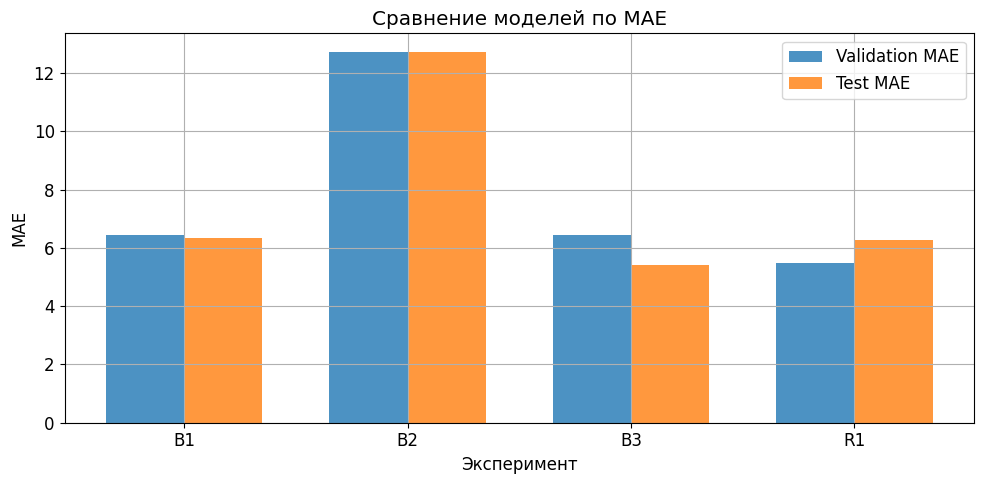

In [11]:
# Сохранение runs.csv
results_df = pd.DataFrame(experiments_results)
results_df.to_csv('artifacts/runs.csv', index=False)
print('Сохранено: artifacts/runs.csv')
display(results_df)

# Сохранение лучшей GRU модели
torch.save(gru_model.state_dict(), 'artifacts/best_gru.pt')
print('Сохранено: artifacts/best_gru.pt')

# Сохранение конфига GRU
with open('artifacts/best_gru_config.json', 'w', encoding='utf-8') as f:
    json.dump(gru_config, f, indent=2, ensure_ascii=False)
print('Сохранено: artifacts/best_gru_config.json')
# График сравнения baseline по MAE на validation
fig, ax = plt.subplots(figsize=(10, 5))
exp_ids = [r['experiment_id'] for r in experiments_results]
val_maes = [r['best_val_mae'] for r in experiments_results]
test_maes = [r['test_mae'] for r in experiments_results]

x = np.arange(len(exp_ids))
width = 0.35

ax.bar(x - width/2, val_maes, width, label='Validation MAE', alpha=0.8)
ax.bar(x + width/2, test_maes, width, label='Test MAE', alpha=0.8)
ax.set_xlabel('Эксперимент')
ax.set_ylabel('MAE')
ax.set_title('Сравнение моделей по MAE')
ax.set_xticks(x)
ax.set_xticklabels(exp_ids)
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

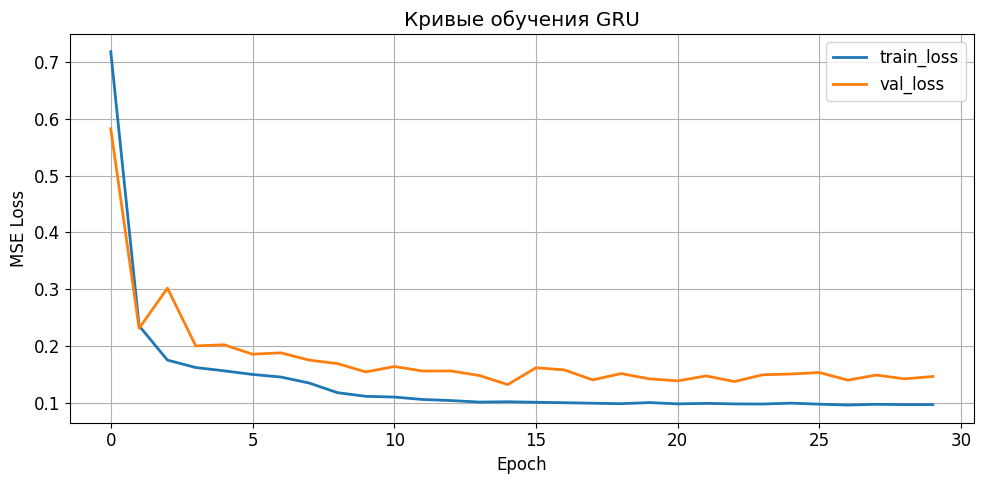


Лучшая модель по validation MAE: R1


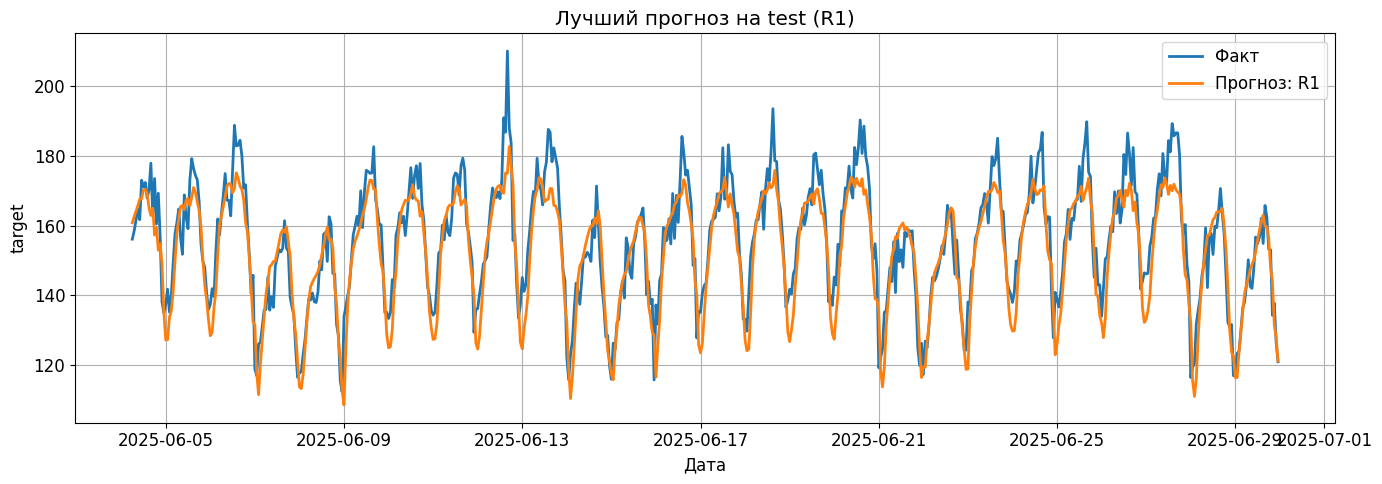

In [12]:
# Кривые обучения GRU
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gru_history['train_loss'], label='train_loss', lw=2)
ax.plot(gru_history['val_loss'], label='val_loss', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Кривые обучения GRU')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# График лучшего прогноза на test
best_exp = min(experiments_results, key=lambda x: x['best_val_mae'])
print(f'\nЛучшая модель по validation MAE: {best_exp["experiment_id"]}')

pred_map = {
    'B1': test_pred_naive,
    'B2': test_pred_ma7,
    'B3': test_pred_ridge,
    'R1': gru_test_pred
}

best_pred = pred_map[best_exp['experiment_id']]

fig, ax = plt.subplots(figsize=(14, 5))
test_dates = test_feat['date'].values

if best_exp['experiment_id'] == 'R1':
    # Для GRU нужно скорректировать даты (window_size сдвиг)
    test_dates = test_feat['date'].iloc[WINDOW_SIZE:].values
    ax.plot(test_dates, gru_test_true, label='Факт', lw=2)
    ax.plot(test_dates, best_pred, label=f'Прогноз: {best_exp["experiment_id"]}', lw=2)
else:
    ax.plot(test_dates, y_test.values, label='Факт', lw=2)
    ax.plot(test_dates, best_pred, label=f'Прогноз: {best_exp["experiment_id"]}', lw=2)

ax.set_xlabel('Дата')
ax.set_ylabel('target')
ax.set_title(f'Лучший прогноз на test ({best_exp["experiment_id"]})')
ax.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

5. Итоговая таблица результатов

In [13]:
summary_df = results_df[['experiment_id', 'best_val_mae', 'test_mae', 'best_val_rmse', 'test_rmse']].copy()
summary_df = summary_df.sort_values('best_val_mae')
display(summary_df)

best_model = summary_df.iloc[0]['experiment_id']
print(f'\n Лучшая модель по validation MAE: {best_model}')
print(f'   Test MAE лучшей модели: {summary_df.iloc[0]["test_mae"]:.4f}')

,experiment_id,best_val_mae,test_mae,best_val_rmse,test_rmse
3,R1,5.489176,6.277660,7.094221,7.975423
2,B3,6.441301,5.414188,7.944266,6.927580
0,B1,6.443406,6.338019,8.203532,8.059906
1,B2,12.723717,12.725250,15.236326,15.226179



 Лучшая модель по validation MAE: R1
   Test MAE лучшей модели: 6.2777
